# 7. The volatility smile: SABR

## Objective

Notebooks 01-06 built a discount curve, priced linear instruments off it,
measured interest-rate risk, and fitted a one-factor Hull-White model to a
*single* at-the-money normal volatility per (expiry, tenor). A single vol is
not how the swaption and cap market quotes: it quotes a **smile** — a normal
volatility that varies with the strike, falling as the strike rises (downward
skew) and curving up at the wings (convexity). A model that prices every
strike at the ATM vol misprices away-from-the-money options, and a risk report
built on it understates the tail.

This notebook fits the **SABR** stochastic-volatility model (Hagan, Kumar,
Lesniewski & Woodward 2002) to an illustrative smile. SABR is the market's
standard smile parametrization: three parameters — a volatility level, a
correlation (the skew), and a volatility-of-volatility (the curvature) — plus
a fixed CEV exponent. Calibration is a least-squares fit to the smile, and the
fitted parameters have a direct economic reading.

## Data

The smile is the packaged dataset `illustrative_swaption_smile`: constructed,
not observed — it is not market data and not a fit to any traded price (see
`DATA_SOURCES.md`). For a fixed illustrative ATM forward of 3%, it carries a
normal volatility at seven strikes per (expiry, tenor) on a small grid. Its
shape is market-plausible by construction: negative skew and positive
convexity, plus a small quartic term that a quadratic smile cannot reproduce —
so a SABR fit leaves a *measured* residual rather than a planted exact fit.

The forward is the generator's fixed constant (3%), not a rate implied by the
repository's USD curve: the vol grid is illustrative and self-contained.

In [1]:
from datetime import date, timedelta

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from yieldcurve.market.snapshot import Snapshot
from yieldcurve.models.sabr import calibrate, sabr_normal_vol

ASOF = date(2026, 7, 24)
snapshot = Snapshot(ASOF)

smile = snapshot.load("illustrative_swaption_smile")
print("smile columns:", list(smile.columns))
print("expiries:", sorted(smile["expiry"].unique()))
print()
print(smile.head(14).to_string(index=False))

smile columns: ['expiry', 'maturity', 'strike', 'vol']
expiries: ['2027-07-24', '2028-07-23', '2031-07-24']

    expiry   maturity  strike      vol
2027-07-24 2032-07-23   0.015 104.9680
2027-07-24 2032-07-23   0.020  96.3137
2027-07-24 2032-07-23   0.025  89.0027
2027-07-24 2032-07-23   0.030  82.8967
2027-07-24 2032-07-23   0.035  77.9498
2027-07-24 2032-07-23   0.040  74.2079
2027-07-24 2032-07-23   0.045  71.8093
2028-07-23 2033-07-23   0.015 105.9215
2028-07-23 2033-07-23   0.020  97.1886
2028-07-23 2033-07-23   0.025  89.8111
2028-07-23 2033-07-23   0.030  83.6497
2028-07-23 2033-07-23   0.035  78.6578
2028-07-23 2033-07-23   0.040  74.8820
2028-07-23 2033-07-23   0.045  72.4616


In [2]:
# The ATM grid is recovered where strike == forward. The smile is the variation
# of vol *around* that ATM point at a fixed expiry.
atm = smile[smile["strike"] == 0.03]
print("ATM normal vols (bp) by expiry:")
print(atm[["expiry", "vol"]].to_string(index=False))

ATM normal vols (bp) by expiry:
    expiry     vol
2027-07-24 82.8967
2028-07-23 83.6497
2031-07-24 64.5847


In [3]:
# ## Theory
#
# SABR models the forward as a CEV process with stochastic volatility:
#
# $$ dF_t = \alpha_t F_t^{\beta}\, dW_t^1, \qquad
#    d\alpha_t = \nu\, \alpha_t\, dW_t^2, \qquad
#    d\langle W^1, W^2\rangle_t = \rho\, dt $$
#
# - $\alpha$ — the volatility *level* (normal vol scale);
# - $\beta \in [0,1]$ — the CEV exponent: $\beta=0$ is the *normal* model,
#   $\beta=1$ the lognormal model;
# - $\rho \in (-1,1)$ — the forward-vol correlation, which is the smile's
#   **skew**: $\rho<0$ means volatility rises when the forward falls, the
#   characteristic downward-sloping smile;
# - $\nu \ge 0$ — the volatility-of-volatility, the smile's **convexity**.
#
# There is no closed-form option price; Hagan et al. derive a leading-order
# asymptotic implied volatility (an approximation, not an exact result). In the
# normal form, matching the repository's Bachelier convention:
#
# $$ \sigma_N(F,K) = \alpha\,\frac{z}{x(z)}
#    \left[1 + \frac{2-3\rho^2}{24}\,\nu^2 T\right], \qquad
#    z = \frac{\nu}{\alpha}\sqrt{FK}\,\ln\frac{F}{K}, $$
#
# $$ x(z) = \ln\!\left(\frac{\sqrt{1-2\rho z+z^2}+z-\rho}{1-\rho}\right). $$
#
# Two conventions are worth stating. **Normal vs lognormal:** this market quotes
# *normal* volatility in basis points (see notebook 06's Bachelier note), and
# the normal SABR is the coherent base model for the low/negative-rate regime
# the repository's EUR/SEK curves document, so $\beta=0$ is used. **Moneyness:**
# the formula's $z$ uses $\sqrt{FK}\,\ln(F/K)$ (QuantLib's convention), not
# $F-K$; the two agree at the money and diverge only in the wings. The code
# follows QuantLib's formula exactly, which is why the parity tests are a tight
# equality rather than an approximate match.
#
# ## Method
#
# $\beta$ is fixed at $0$ (fitting it is ill-conditioned — it is nearly
# collinear with $\rho$), and $(\alpha,\rho,\nu)$ are fitted by least squares on
# the normal-vol residual. The calibration rejects a boundary fit, a
# rank-deficient or ill-conditioned Jacobian, and a start-sensitive solution —
# the same hardening the Hull-White and parametric fits apply (notebook 06,
# notebook 03).

In [4]:
# Fit SABR to the 2-year-expiry smile (the 1y and 5y are shown as context).
FORWARD = 0.03
expiry_years = 2.0
expiry_date = (ASOF + timedelta(days=int(expiry_years * 365.25))).isoformat()

rows = smile[smile["expiry"] == expiry_date].sort_values("strike")
strikes = rows["strike"].to_numpy(dtype=float)
market_bp = rows["vol"].to_numpy(dtype=float)
market = market_bp / 1e4  # bp -> decimal

result = calibrate(FORWARD, strikes, market, expiry_years, beta=0.0)
print(f"fit to {result.n_strikes} strikes at expiry {expiry_years}y:")
print(f"  alpha = {result.alpha:.5f}  (normal vol level, decimal; {result.alpha * 1e4:.2f} bp)")
print(f"  rho   = {result.rho:+.4f}  (skew: negative => downward smile)")
print(f"  nu    = {result.nu:.4f}   (vol-of-vol: curvature)")
print(f"  rmse  = {result.rmse_vol_bp:.4f} bp")
print(f"  jacobian rank = {result.jacobian_rank}, cond = {result.jacobian_condition:.2e}")

fit to 7 strikes at expiry 2.0y:
  alpha = 0.00823  (normal vol level, decimal; 82.34 bp)
  rho   = -0.5599  (skew: negative => downward smile)
  nu    = 0.4469   (vol-of-vol: curvature)
  rmse  = 0.6217 bp
  jacobian rank = 3, cond = 9.55e+02


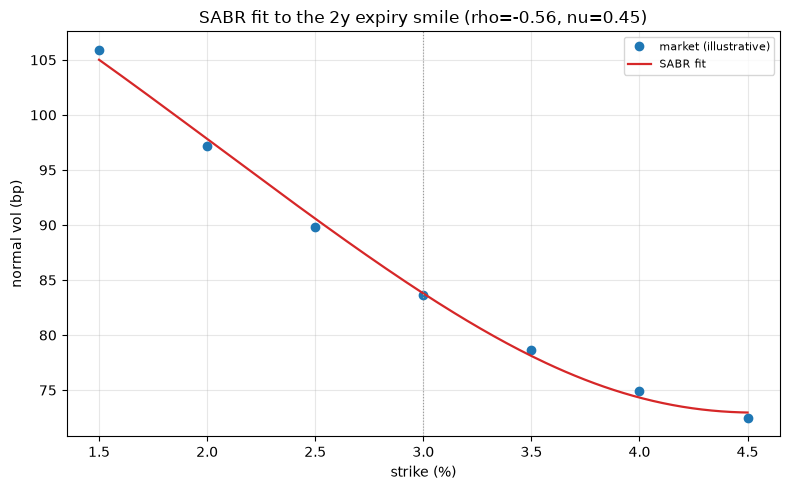

In [5]:
# ## Results
#
# **The fitted parameters have a direct reading.** $\rho<0$ is the downward
# skew: volatility rises as the strike falls, because a lower strike is a
# receiver position and a falling rate both *lowers* the strike and *raises*
# volatility. $\nu>0$ is the convexity: the smile is not a straight line, and a
# two-parameter (level + skew) model would understate the wings.
#
# **The residual is measured, not asserted away.** The quartic term in the
# synthetic smile is exactly the part a quadratic SABR smile cannot reach, so
# the fit leaves a small, visible residual — the honest signature that SABR is a
# parsimonious approximation, not the data-generating process.

grid = np.linspace(strikes.min(), strikes.max(), 200)
fitted = np.array(
    [
        sabr_normal_vol(FORWARD, k, result.alpha, 0.0, result.rho, result.nu, expiry_years)
        for k in grid
    ]
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(strikes * 100, market_bp, "o", label="market (illustrative)", color="#1f77b4")
ax.plot(grid * 100, fitted * 1e4, "-", label="SABR fit", color="#d62728", lw=1.6)
ax.axvline(FORWARD * 100, color="#999999", ls=":", lw=0.8)
ax.set_xlabel("strike (%)")
ax.set_ylabel("normal vol (bp)")
ax.set_title(f"SABR fit to the 2y expiry smile (rho={result.rho:+.2f}, nu={result.nu:.2f})")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

In [6]:
# The per-strike residuals, in basis points, show the quartic shape the fit
# leaves behind:
residuals_bp = (result.model_vols - np.asarray(result.market_vols)) * 1e4
print(
    pd.DataFrame(
        {
            "strike": strikes,
            "market_bp": market_bp,
            "model_bp": np.asarray(result.model_vols) * 1e4,
            "residual_bp": residuals_bp,
        }
    ).to_string(index=False)
)

 strike  market_bp   model_bp  residual_bp
  0.015   105.9215 105.013378    -0.908122
  0.020    97.1886  97.821356     0.632756
  0.025    89.8111  90.579747     0.768647
  0.030    83.6497  83.788500     0.138800
  0.035    78.6578  78.104232    -0.553568
  0.040    74.8820  74.325796    -0.556204
  0.045    72.4616  72.965816     0.504216


In [7]:
# ## How the smile changes across expiries
#
# Each expiry is fitted separately; the fitted $(\alpha,\rho,\nu)$ are a
# point-in-time smile, not a volatility *surface* (a full surface would fit the
# cube across expiry x tenor x strike jointly, which is beyond this notebook's
# scope). The ATM level falls with expiry (the hump is at ~1-2y, matching the
# ATM grid's construction), while the skew and curvature stay stable.

for ey in (1.0, 2.0, 5.0):
    ed = (ASOF + timedelta(days=int(ey * 365.25))).isoformat()
    rr = smile[smile["expiry"] == ed].sort_values("strike")
    fit = calibrate(FORWARD, rr["strike"].to_numpy(), rr["vol"].to_numpy() / 1e4, ey, beta=0.0)
    print(
        f"  expiry {ey:.1f}y: alpha={fit.alpha * 1e4:6.2f} bp  rho={fit.rho:+.3f}  "
        f"nu={fit.nu:.3f}  rmse={fit.rmse_vol_bp:.3f} bp"
    )

  expiry 1.0y: alpha= 82.31 bp  rho=-0.560  nu=0.447  rmse=0.616 bp
  expiry 2.0y: alpha= 82.34 bp  rho=-0.560  nu=0.447  rmse=0.622 bp
  expiry 5.0y: alpha= 63.06 bp  rho=-0.560  nu=0.342  rmse=0.480 bp


In [8]:
# ## Limitations
#
# - **Asymptotic, not exact.** The Hagan formula is a leading-order expansion in
#   time and vol-of-vol; it is accurate for the tenors and smiles here but is an
#   approximation, and it can misbehave at extreme strikes or very long
#   expiries.
# - **Positive forward and strike only.** The formula evaluates $\ln(F/K)$ and
#   $(FK)^{\beta/2}$, so $F,K>0$ are required. A market with non-positive rates
#   needs a *shifted* SABR (a positive displacement), not implemented here.
# - **Illustrative data.** The smile is constructed, not observed; the fitted
#   parameters describe the synthetic shape, not a traded market, and the
#   forward is the generator's constant rather than a curve-implied rate.
# - **Single expiry.** Each expiry is a standalone fit; there is no joint
#   surface calibration and no arbitrage-free interpolation across expiries.
#
# ## Regulatory context
#
# The same boundary as the Hull-White notebook applies: this is a least-squares
# fit to a constructed grid, not a validated pricing or risk model. A bank's
# internal model governance, independent validation and internal-capital
# assessment sit under CRD Articles 74 (governance), 84 (IRRBB) and 101
# (ICAAP); none of that machinery is present here. The cross-check against
# QuantLib in `tests/models/test_sabr.py` is software verification — two
# implementations of the same closed form — not empirical or regulatory model
# validation. Under IFRS 13, an illustrative volatility is an unobservable
# (Level 3) input, and no automatic fair-value classification follows from
# using it; this notebook performs no entity-level fair-value measurement.